In [1]:
import pandas as pd

df = pd.read_csv("/content/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [3]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


In [4]:
df.duplicated().sum()
df = df.drop_duplicates()

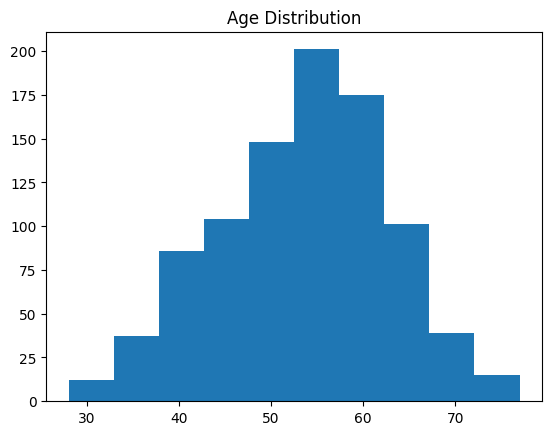

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['Age'])
plt.title("Age Distribution")
plt.show()

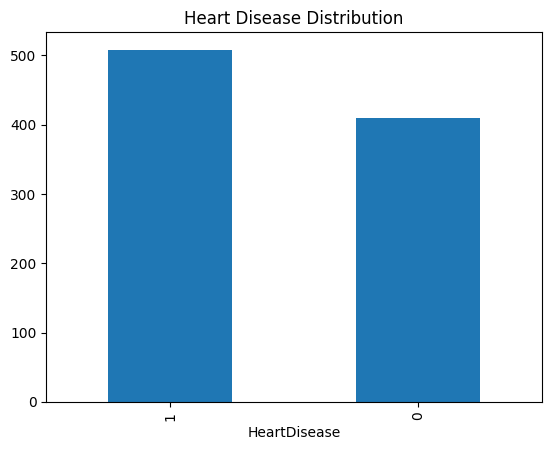

In [6]:
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8532608695652174
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [15]:
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.875


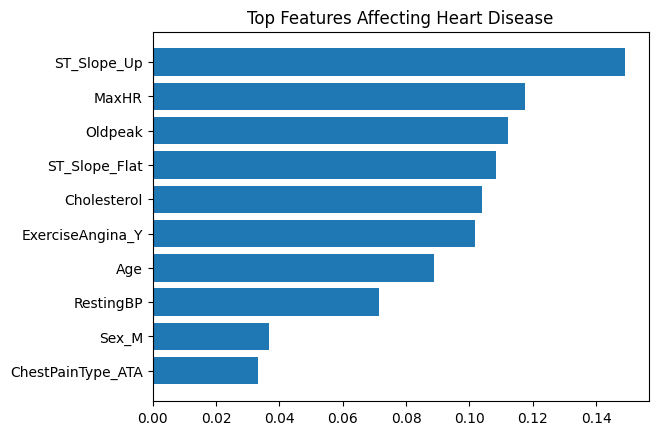

In [16]:
import numpy as np

importances = rf.feature_importances_
features = X.columns

sorted_idx = np.argsort(importances)[-10:]

plt.barh(features[sorted_idx], importances[sorted_idx])
plt.title("Top Features Affecting Heart Disease")
plt.show()

In [17]:
import joblib

joblib.dump(rf, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

/tmp/ipykernel_12289/1413641030.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby('AgeGroup')['HeartDisease'].mean()


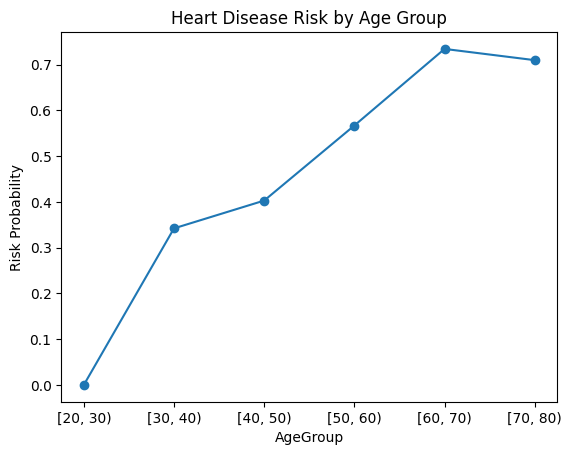

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,80], right=False)

age_risk = df.groupby('AgeGroup')['HeartDisease'].mean()

age_risk.plot(kind='line', marker='o')
plt.title("Heart Disease Risk by Age Group")
plt.ylabel("Risk Probability")
plt.show()

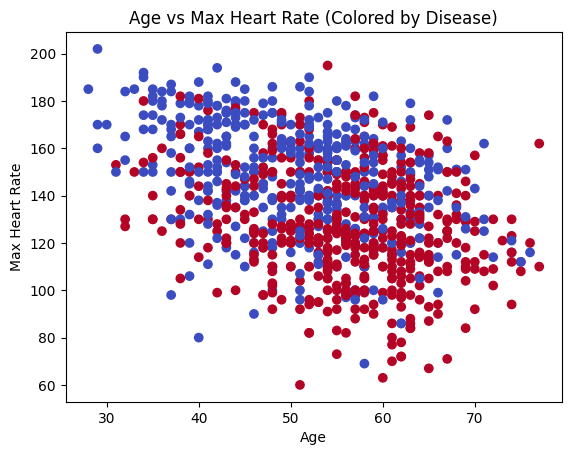

In [20]:
plt.scatter(df['Age'], df['MaxHR'], c=df['HeartDisease'], cmap='coolwarm')
plt.title("Age vs Max Heart Rate (Colored by Disease)")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.show()